In [2]:
! pip install faiss-cpu


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\VİCTUS\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [2]:
import urllib.request as request 
import tarfile 
import numpy as np 
import os 
import faiss 
import matplotlib.pyplot as plt 
import time 
import psutil 
import tempfile 
# Sabitler
sift_url = "ftp://ftp.irisa.fr/local/texmex/corpus/sift.tar.gz"
sift_archive = "sift.tar.gz"
sift_dir = "sift"


base_file = f"{sift_dir}/sift_base.fvecs"
query_file = f"{sift_dir}/sift_query.fvecs"
gt_file = f"{sift_dir}/sift_groundtruth.ivecs"
len_file = f"{sift_dir}/sift_learn.fvecs" 


# İndir ve çıkar 
if  not os.path.exists(sift_archive): 
    print ( "sift.tar.gz indiriliyor..." )
    request.urlretrieve(sift_url, sift_archive) 
if  not os.path.exists(base_file): 
    print ( "Arşiv çıkarılıyor..." ) 
    with tarfile. open (sift_archive, "r:gz" ) as tar: 
        tar.extractall()

In [3]:
# Yükleyiciler 
def read_fvecs(filename): 
    with open(filename, "rb") as f: 
        d = np.fromfile(f, dtype=np.int32, count=1)[0] 
        f.seek(0) 
        data = np.fromfile(f, dtype=np.float32) 
        return data.reshape(-1, d + 1)[:, 1:]
def read_ivecs(filename): 
    with open(filename, "rb") as f: 
        d = np.fromfile(f, dtype=np.int32, count=1)[0] 
        f.seek(0) 
        data = np.fromfile(f, dtype=np.int32) 
        return data.reshape(-1, d + 1)[:, 1:]
    
    
# Verileri yükle 
xb = read_fvecs(base_file) 
xq = read_fvecs(query_file) 
I_true = read_ivecs(gt_file) 
xt = read_fvecs(len_file) 
print("SIFT1M Veri Kümesi Yüklendi") 
print(f"Temel: {xb.shape}, Sorgu: {xq.shape}, Doğru Değer: {I_true.shape} , Öğrenme: {xt.shape}")

SIFT1M Veri Kümesi Yüklendi
Temel: (1000000, 128), Sorgu: (10000, 128), Doğru Değer: (10000, 100) , Öğrenme: (100000, 128)


In [5]:
# FAISS index’i oluşturmak için gerekli olan vektör boyutu
d = xb.shape[1]

#İnşa süresi
start_build = time.time()

# IndexFlatL2: brute-force (exact nearest neighbor) arama yapar
index_flat = faiss.IndexFlatL2(d)

# Veri tabanı vektörleri index’e eklenir
index_flat.add(xb)
end_build = time.time()
build_time = end_build - start_build
print(f"\nBuild Time: {build_time:.6f} saniye")

# Index içinde kaç vektör olduğu kontrol edilir
print("Dizindeki vektör sayısı:", index_flat.ntotal)

# QUERY (Sorgu ayarları)
#Her sorgu için kaç komşu aranacak
k = 100

#Kaç tane sorgu yapılacak ona bakar 
num_queries_to_test = len(xq)
print(f"\nIndexFlatL2 ile {num_queries_to_test} sorgu aranıyor...")

# QUERY LATENCY (Sorgu süresi)
start_time = time.time()

D_flat, I_flat = index_flat.search(
    xq[:num_queries_to_test],
    k
)

end_time = time.time()

query_time = end_time - start_time
avg_latency = query_time / num_queries_to_test

print(f"Toplam Query Süresi: {query_time:.6f} saniye")
print(f"Ortalama Query Latency: {avg_latency:.6f} saniye/sorgu")

# RECALL@10
recall_at_10 = (
    np.any(I_flat[:, :10] == I_true[:num_queries_to_test, 0:1], axis=1)
).mean()

print(f"\nIndexFlatL2 için Recall@10: {recall_at_10:.4f}")


Build Time: 0.437635 saniye
Dizindeki vektör sayısı: 1000000

IndexFlatL2 ile 10000 sorgu aranıyor...
Toplam Query Süresi: 22.339810 saniye
Ortalama Query Latency: 0.002234 saniye/sorgu

IndexFlatL2 için Recall@10: 1.0000


In [8]:
# --- IndexIVFFlat ---
nlist = 1000 # Hücre sayısı
quantizer = faiss.IndexFlatL2(d)
index_ivf = faiss.IndexIVFFlat(quantizer, d, nlist)

# İNŞA SÜRESİ (Eğitim gerektirir.)
start_build = time.time()
index_ivf.train(xt)  # 'xt' öğrenme kümesi ile eğitilir
index_ivf.add(xb)    # 1M vektör eklenir
end_build = time.time()

build_time_ivf=end_build - start_build
print(f"\n[IVF] Build Time: {build_time_ivf:.6f} saniye")

# SORGU SÜRESİ
index_ivf.nprobe = 10 # Kaç hücre taranacak?
start_search = time.time()
D_ivf, I_ivf = index_ivf.search(xq, k)
end_search = time.time()

query_time = end_search - start_search
print(f"[IVF] Ortalama Latency: {query_time/len(xq):.6f} saniye/sorgu")

# RECALL@10
recall_ivf = (np.any(I_ivf[:, :10] == I_true[:, 0:1], axis=1)).mean()
print(f"[IVF] Recall@10: {recall_ivf:.4f}")



[IVF] Build Time: 4.531842 saniye
[IVF] Ortalama Latency: 0.000214 saniye/sorgu
[IVF] Recall@10: 0.9163


In [11]:
# --- IndexHNSWFlat ---
M = 32 # Her düğümün kuracağı bağ sayısı
index_hnsw = faiss.IndexHNSWFlat(d, M)

# İNŞA SÜRESİ
start_build = time.time()
index_hnsw.add(xb) # HNSW eğitim gerektirmez, direkt eklenir
end_build = time.time()

build_time_hnsw=end_build - start_build
print(f"\n[HNSW] Build Time: {build_time_hnsw:.6f} saniye")

# SORGU SÜRESİ
start_search = time.time()
D_hnsw, I_hnsw = index_hnsw.search(xq, k)
end_search = time.time()

query_time_hnsw = end_search - start_search
print(f"[HNSW] Ortalama Latency: {query_time_hnsw/len(xq):.6f} saniye/sorgu")

# RECALL@10
recall_hnsw = (np.any(I_hnsw[:, :10] == I_true[:, 0:1], axis=1)).mean()
print(f"[HNSW] Recall@10: {recall_hnsw:.4f}")


[HNSW] Build Time: 60.364404 saniye
[HNSW] Ortalama Latency: 0.000033 saniye/sorgu
[HNSW] Recall@10: 0.9109


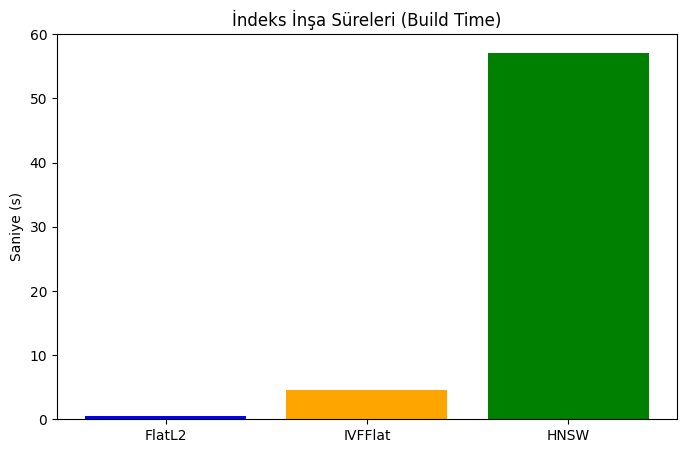

In [10]:
#İNŞA SÜRESİ KARŞILAŞTIRILMASI

labels = ['FlatL2', 'IVFFlat', 'HNSW']
build_times = [build_time, build_time_ivf, build_time_hnsw]

plt.figure(figsize=(8, 5))
plt.bar(labels, build_times, color=['blue', 'orange', 'green'])
plt.ylabel('Saniye (s)')
plt.title('İndeks İnşa Süreleri (Build Time)')
plt.show()

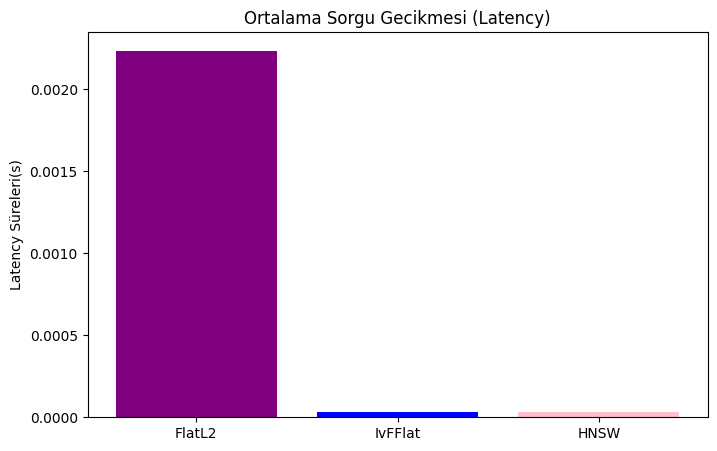

In [13]:
#LATENCY SÜRE KARŞILAŞTIRILMASI
labels=["FlatL2","IvFFlat","HNSW"]
latencies = [avg_latency, query_time/len(xq), query_time_hnsw/len(xq)]

plt.figure(figsize=(8, 5))
plt.bar(labels,latencies,color=['purple','blue','pink'])
plt.ylabel("Latency Süreleri(s)")
plt.title("Ortalama Sorgu Gecikmesi (Latency)")
plt.show()


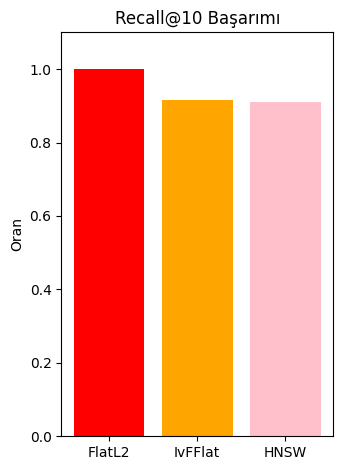

In [19]:
#RECALL@10 DEĞER KARŞILAŞTIRMALARI
labels=["FlatL2","IvFFlat","HNSW"]
recalls = [recall_at_10, recall_ivf, recall_hnsw]

plt.subplot(1, 2, 2)
plt.bar(labels, recalls, color=['red', 'orange', 'pink'])
plt.ylim(0, 1.1)
plt.title('Recall@10 Başarımı')
plt.ylabel('Oran')
plt.tight_layout()
plt.show()